# Inicjalizacja | Feature Engineering | XGBoost

In [1]:
import pandas as pd
import numpy as np
import glob
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

print("="*80)
print(">>> KROK 1: INICJALIZACJA, INŻYNIERIA CECH I TRENING XGBOOST <<<")
print("="*80)

# ==========================================
# 1. WCZYTANIE DANYCH I FILTROWANIE 
# ==========================================
df_train_raw = pd.read_csv('../dane/gotowe_ml/honeypot_ml_ready.csv', low_memory=False)

# >>> KLUCZOWA ZMIANA ARCHITEKTONICZNA <<<
classes_to_drop = ['Background Noise', 'Rare / Minor Anomalies']
df_train_raw = df_train_raw[~df_train_raw['Refined_Label'].isin(classes_to_drop)].copy()

test_files = glob.glob('../dane/testowe/*.csv')
dfs_test = [pd.read_csv(f, on_bad_lines="skip", low_memory=False) for f in test_files]
df_test_raw = pd.concat(dfs_test, ignore_index=True) if dfs_test else pd.DataFrame()

print(f"[*] Wczytano Złoty Standard (Tylko czyste kampanie): {len(df_train_raw)} rekordów.")
print(f"[*] Wczytano Surowe Logi (Przyszłość): {len(df_test_raw)} rekordów.")

# ==========================================
# 2. DEFINICJA CECH
# ==========================================
FEATURES = [
    'Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 
    'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Bytes_Ratio', 
    'is_well_known_port', 'is_ephemeral_port',
    'Proto_Enc', 'State_Enc', 'Dport_Num'
]

known_protos = {p: i for i, p in enumerate(df_train_raw['Proto'].astype(str).unique())}
known_states = {s: i for i, s in enumerate(df_train_raw['State'].astype(str).unique())}

def safe_encode(val, mapping_dict): return mapping_dict.get(str(val), -1)
def safe_port(p):
    try: return int(str(p), 16) if str(p).startswith('0x') else int(float(p))
    except: return 0

# ==========================================
# 3. PRZYGOTOWANIE ZBIORU TRENINGOWEGO (ZŁOTY STANDARD)
# ==========================================
print("[*] Formowanie wektorów dla XGBoost...")
df_train = df_train_raw.copy()
df_train['Proto_Enc'] = df_train['Proto'].apply(lambda x: safe_encode(x, known_protos))
df_train['State_Enc'] = df_train['State'].apply(lambda x: safe_encode(x, known_states))
df_train['Dport_Num'] = df_train['Dport'].apply(safe_port)

X_train_full = df_train[FEATURES].fillna(0)

# Kodowanie etykiet (Wymóg XGBoosta - musi mieć od 0 do N-1)
le_target = LabelEncoder()
y_train_full_encoded = le_target.fit_transform(df_train['Refined_Label'])

# Podział na Train i Val 
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full_encoded, test_size=0.2, random_state=42, stratify=y_train_full_encoded
)

# ==========================================
# 4. FUNKCJA DLA SUROWYCH DANYCH Z PRZYSZŁOŚCI 
# ==========================================
def prepare_future_logs(df_input):
    df = df_input.copy()
    
    for col in ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 'SrcBytes', 'DstBytes']:
        df[col] = pd.to_numeric(df.get(col, 0), errors='coerce').fillna(0)
        
    # Asymetria na surowych wartościach
    df['Bytes_per_Pkt'] = df['TotBytes'] / (df['TotPkts'] + 1e-6)
    df['Pkts_Freq']     = df['TotPkts'] / (df['Dur'] + 1e-6)
    df['Pkts_Ratio']    = df['SrcPkts'] / (df['DstPkts'] + 1e-6)
    df['Bytes_Ratio']   = df.get('SrcBytes', 0) / (df.get('DstBytes', 0) + 1e-6)

    # Flagi portów
    df['Dport_Num'] = df.get('Dport', 0).apply(safe_port)
    df['is_well_known_port'] = ((df['Dport_Num'] > 0) & (df['Dport_Num'] <= 1024)).astype(int)
    df['is_ephemeral_port'] = (df['Dport_Num'] >= 49152).astype(int)

    # Logarytmowanie (Zgodność z NB01)
    cols_to_log = ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 
                   'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Bytes_Ratio']
    for col in cols_to_log:
        df[col] = np.log1p(df[col].clip(lower=0))

    df['Proto_Enc'] = df.get('Proto', '').astype(str).apply(lambda x: safe_encode(x, known_protos))
    df['State_Enc'] = df.get('State', '').astype(str).apply(lambda x: safe_encode(x, known_states))
    
    for f in FEATURES:
        if f not in df.columns: df[f] = 0
    return df[FEATURES].fillna(0)

# ==========================================
# 5. TRENING MODELU XGBOOST
# ==========================================
print("[*] Trenowanie modelu XGBoost (Gradient Boosting)...")

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,          # Więcej drzew dla precyzji
    learning_rate=0.1,         # Stabilny krok uczenia
    max_depth=6,               # Zapobiega przeuczeniu
    random_state=42, 
    n_jobs=-1, 
    eval_metric='mlogloss',
    tree_method='hist'         # Przyspiesza trening na nowoczesnych procesorach
)

xgb_clf.fit(X_train, y_train, sample_weight=sample_weights)

# Szybki check wewnętrzny
y_pred_val = xgb_clf.predict(X_val)
acc = (y_pred_val == y_val).mean()
print(f"[+] Model XGBoost uzbrojony! Precyzja walidacyjna (Złoty Standard): {acc*100:.2f}%\n")

>>> KROK 1: INICJALIZACJA, INŻYNIERIA CECH I TRENING XGBOOST <<<
[*] Wczytano Złoty Standard (Tylko czyste kampanie): 64657 rekordów.
[*] Wczytano Surowe Logi (Przyszłość): 44308 rekordów.
[*] Formowanie wektorów dla XGBoost...
[*] Trenowanie modelu XGBoost (Gradient Boosting)...
[+] Model XGBoost uzbrojony! Precyzja walidacyjna (Złoty Standard): 99.99%



# Wykresy ROC i PR

>>> KROK 2: EWALUACJA WEWNĘTRZNA I WIZUALIZACJA (XGBOOST) <<<
[*] Generowanie raportu klasyfikacji (Precision, Recall, F1-Score)...

                         RAPORT KLASYFIKACJI - XGBOOST                          
                                    precision    recall  f1-score   support

                  CoAP Enumeration     1.0000    1.0000    1.0000         8
                   DNS Enumeration     1.0000    1.0000    1.0000        32
                  HTTP Brute Force     1.0000    1.0000    1.0000        15
       HTTP Cross-Protocol Anomaly     0.9000    1.0000    0.9474         9
ICMP Fingerprinting (OS Detection)     1.0000    1.0000    1.0000       614
            ISAKMP_VPN Brute Force     1.0000    1.0000    1.0000        56
                  LDAP Enumeration     1.0000    1.0000    1.0000        37
        Long-lived Session Anomaly     1.0000    1.0000    1.0000        64
       Mass TCP Port Scanning (L4)     1.0000    1.0000    1.0000     11767
                   NTP En

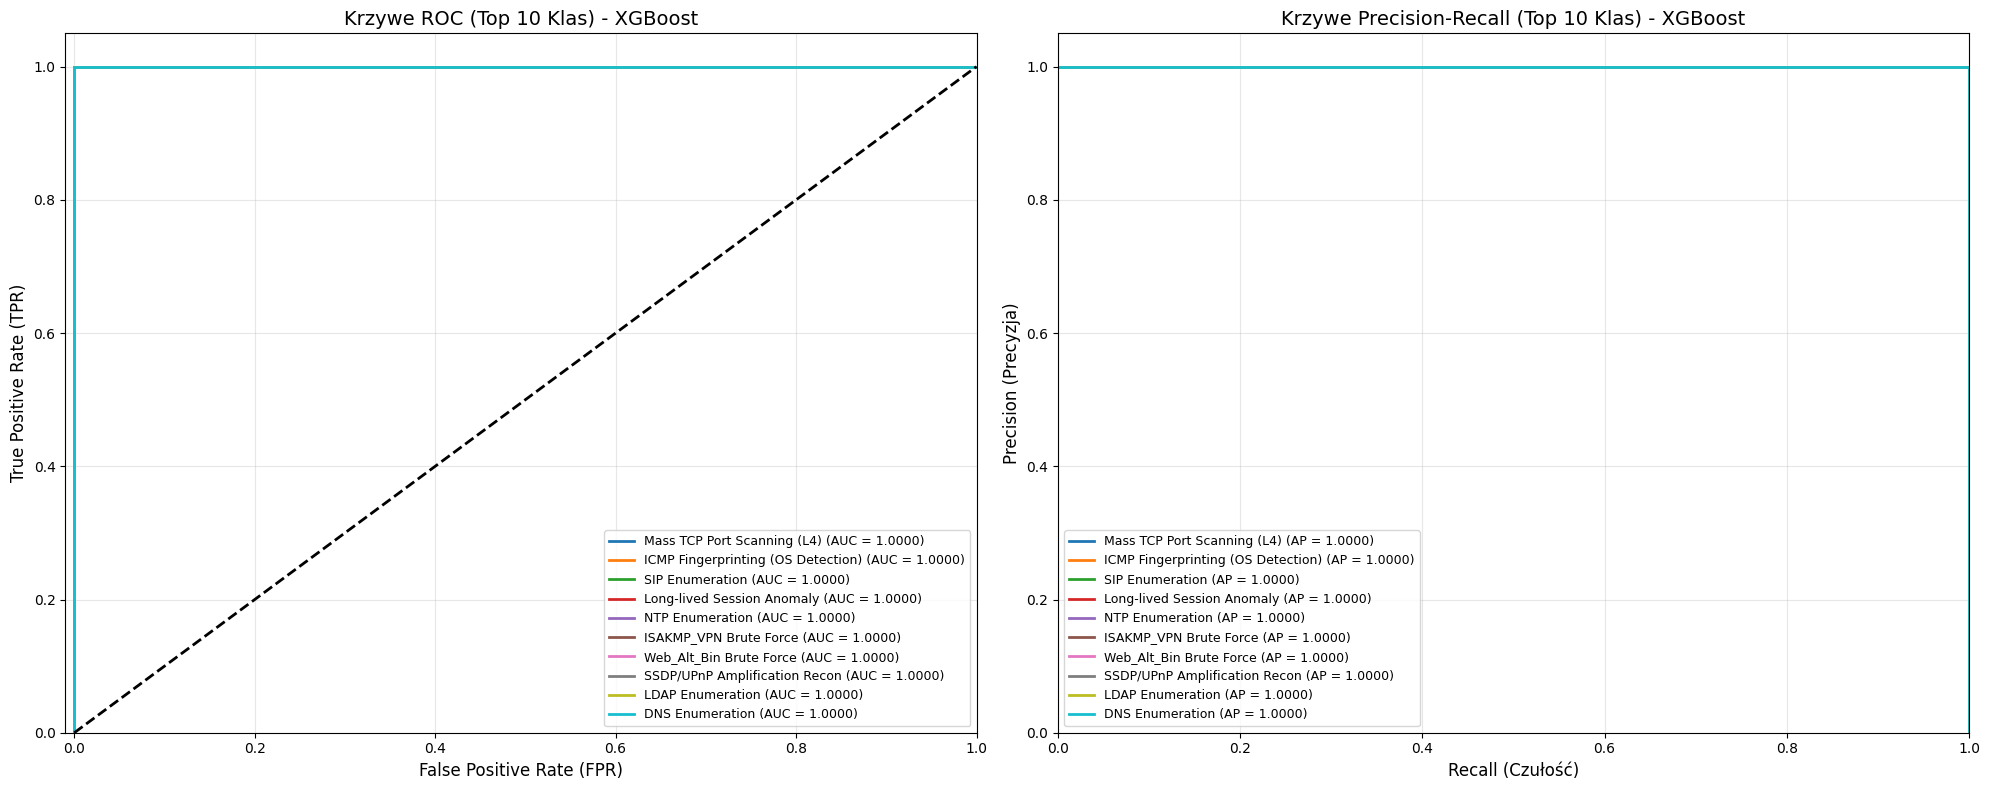

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, classification_report
from sklearn.preprocessing import label_binarize
import os
import numpy as np
import pandas as pd

print("="*80)
print(">>> KROK 2: EWALUACJA WEWNĘTRZNA I WIZUALIZACJA (XGBOOST) <<<")
print("="*80)

output_dir = '../wykresy'
if not os.path.exists(output_dir): os.makedirs(output_dir)

# 1. RAPORT KLASYFIKACJI (TABELA F1-SCORE Z DEKODOWANIEM ETYKIET)
print("[*] Generowanie raportu klasyfikacji (Precision, Recall, F1-Score)...")
y_pred_encoded = xgb_clf.predict(X_val)

# Tłumaczymy cyferki z powrotem na nazwy ataków, żeby tabela była ludzka
y_val_decoded = le_target.inverse_transform(y_val)
y_pred_decoded = le_target.inverse_transform(y_pred_encoded)

print("\n" + "="*80)
print(f"{'RAPORT KLASYFIKACJI - XGBOOST':^80}")
print("="*80)
print(classification_report(y_val_decoded, y_pred_decoded, digits=4))
print("="*80 + "\n")

# 2. POBIERANIE WYNIKÓW DO WYKRESÓW
classes_encoded = xgb_clf.classes_
y_val_bin = label_binarize(y_val, classes=classes_encoded)
n_classes = y_val_bin.shape[1]

print("[*] Generowanie krzywych ROC i PR dla zbioru walidacyjnego...")
y_score = xgb_clf.predict_proba(X_val)

fpr, tpr, roc_auc = dict(), dict(), dict()
precision, recall, average_precision = dict(), dict(), dict()

# Obliczanie metryk dla każdej zakodowanej klasy
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_val_bin[:, i], y_score[:, i])
    average_precision[i] = average_precision_score(y_val_bin[:, i], y_score[:, i])

# Inteligentne wyciąganie nazw Top 10
top_classes_encoded = pd.Series(y_val).value_counts().head(10).index
colors = sns.color_palette("tab10", len(top_classes_encoded))

# 3. RYSOWANIE WYKRESÓW
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- [A] Krzywa ROC ---
for enc_label, color in zip(top_classes_encoded, colors):
    col_idx = np.where(classes_encoded == enc_label)[0][0] # Szukamy indeksu kolumny
    class_name = le_target.inverse_transform([enc_label])[0] # ODKODOWANIE nazwy!
    
    ax1.plot(fpr[col_idx], tpr[col_idx], color=color, lw=2, label=f'{class_name} (AUC = {roc_auc[col_idx]:.4f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=2)
ax1.set_xlim([-0.01, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax1.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax1.set_title('Krzywe ROC (Top 10 Klas) - XGBoost', fontsize=14)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(alpha=0.3)

# --- [B] Krzywa Precision-Recall ---
for enc_label, color in zip(top_classes_encoded, colors):
    col_idx = np.where(classes_encoded == enc_label)[0][0]
    class_name = le_target.inverse_transform([enc_label])[0] # ODKODOWANIE nazwy!
    
    ax2.plot(recall[col_idx], precision[col_idx], color=color, lw=2, label=f'{class_name} (AP = {average_precision[col_idx]:.4f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Czułość)', fontsize=12)
ax2.set_ylabel('Precision (Precyzja)', fontsize=12)
ax2.set_title('Krzywe Precision-Recall (Top 10 Klas) - XGBoost', fontsize=14)
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
file_path = os.path.join(output_dir, '10_xgb_roc_pr_curves.png') 
plt.savefig(file_path, dpi=300)
print(f"[+] SUKCES! Zapisano wykresy w: {file_path}")
plt.show()

# Inferencja i Paszport DPI

In [3]:
import numpy as np
import pandas as pd

print("="*125)
print(">>> KROK 3: INFERENCJA ZERO-DAY ORAZ PASZPORT DPI (XGBOOST) <<<")
print("="*125)

# 1. PREDYKCJA MODELEM MATKĄ
X_new = prepare_future_logs(df_test_raw)

print(f"[*] Skanowanie {len(X_new)} nowych rekordów (Próg pewności: 75%)...")
CONFIDENCE_THRESHOLD = 0.75

# >>> KLUCZOWE ZMIANY: xgb_clf zamiast clf oraz odkodowanie nazw <<<
probs = xgb_clf.predict_proba(X_new)
max_probs = np.max(probs, axis=1)
pred_indices = np.argmax(probs, axis=1)

predicted_classes_text = le_target.inverse_transform(pred_indices)

# Nałożenie filtru pewności
df_test_raw['System_Decision'] = np.where(max_probs >= CONFIDENCE_THRESHOLD, predicted_classes_text, 'UNKNOWN_Zero_Day')
df_test_raw['Confidence'] = max_probs # Zapisujemy pewność dla celów analitycznych

# 2. RAPORT ZAGROŻEŃ (ZLICZANIE ODRZUTÓW)
report_counts = df_test_raw['System_Decision'].value_counts()
unknown_count = report_counts.get('UNKNOWN_Zero_Day', 0)
unknown_percent = (unknown_count / len(df_test_raw)) * 100

print(f"\n[!] STATYSTYKA PEWNOŚCI MODELU (XGBoost):")
print(f"    - Średnia pewność dla całego ruchu: {max_probs.mean():.4f}")
print(f"    - Ruch zaufany (sklasyfikowany pewnie): {100 - unknown_percent:.2f}%")
print(f"    - Ruch odrzucony jako UNKNOWN (Zero-Day/Szum): {unknown_percent:.2f}%\n")

# 3. GENEROWANIE PASZPORTU DPI DLA DECYZJI MODELU
def get_mode(x):
    m = pd.Series.mode(x)
    return m.iloc[0] if not m.empty else "N/A"

report = df_test_raw.groupby('System_Decision').agg({
    'Dur': 'median',
    'TotPkts': 'median',
    'State': get_mode,
    'Dport': get_mode,
    'Confidence': 'mean', 
    'srcUdata': lambda x: x.dropna().iloc[0] if not x.dropna().empty else "[Brak Payloadu]"
}).reset_index()

report['Liczność'] = report['System_Decision'].map(report_counts)
report = report.sort_values(by='Liczność', ascending=False)

# Zmieniony nagłówek na XGBOOST
print(f"{'DECYZJA MODELU XGBOOST':<35} | {'LICZNOŚĆ':<9} | {'PEWNOŚĆ':<8} | {'PORT':<6} | {'PKT':<4} | {'STATE':<6} | {'PRÓBKA Z PAYLOADU (DPI)'}")
print("-" * 125)

for _, row in report.iterrows():
    # Czyszczenie Payloadu
    p_clean = str(row['srcUdata']).replace('\n', ' ').replace('\r', ' ')
    if len(p_clean) > 35:
        p_clean = p_clean[:32] + "..."
        
    # Czyszczenie portów 
    try: p_port = str(int(float(row['Dport'])))
    except: p_port = str(row['Dport'])
        
    # Graficzne wyróżnienie odrzutów
    label = f">>> {row['System_Decision']} <<<" if row['System_Decision'] == 'UNKNOWN_Zero_Day' else str(row['System_Decision'])
        
    print(f"{label:<35} | {int(row['Liczność']):<9} | {row['Confidence']:<8.2f} | {p_port:<6} | {int(row['TotPkts']):<4} | {str(row['State']):<6} | {p_clean}")
print("="*125)

>>> KROK 3: INFERENCJA ZERO-DAY ORAZ PASZPORT DPI (XGBOOST) <<<
[*] Skanowanie 44308 nowych rekordów (Próg pewności: 75%)...

[!] STATYSTYKA PEWNOŚCI MODELU (XGBoost):
    - Średnia pewność dla całego ruchu: 0.9562
    - Ruch zaufany (sklasyfikowany pewnie): 93.44%
    - Ruch odrzucony jako UNKNOWN (Zero-Day/Szum): 6.56%

DECYZJA MODELU XGBOOST              | LICZNOŚĆ  | PEWNOŚĆ  | PORT   | PKT  | STATE  | PRÓBKA Z PAYLOADU (DPI)
-----------------------------------------------------------------------------------------------------------------------------
Mass TCP Port Scanning (L4)         | 33019     | 1.00     | 445    | 3    | SR_RA  | s[6]=......
SIP_Alt Enumeration                 | 4868      | 0.99     | 5070   | 1    | INT    | s[416]=OPTIONS sip:100@128.199.1...
>>> UNKNOWN_Zero_Day <<<            | 2908      | 0.38     | 3283   | 1    | INT    | s[2]=..
SIP Enumeration                     | 1575      | 1.00     | 5060   | 1    | INT    | s[418]=OPTIONS sip:100@128.199.1...
ICMP